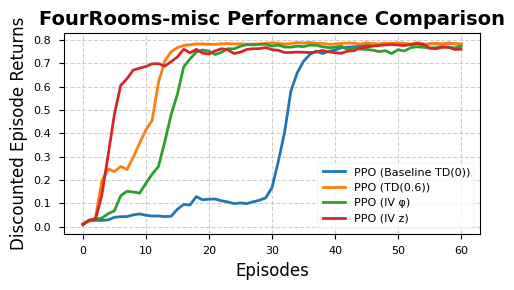

In [2]:
import matplotlib.pyplot as plt
from core.utils import load_run_data
ppo_config, ppo_metrics = load_run_data("ppo/20260513_161819", 'FourRooms-misc', 'results')
ppo_lambda_config, ppo_lambda_metrics = load_run_data("ppo/gae_lambda_06", 'FourRooms-misc', 'results')
iv_ppo_config, iv_ppo_metrics = load_run_data("ppo_iv/20260514_154144", 'FourRooms-misc', 'results')
ivz_ppo_config, ivz_ppo_metrics = load_run_data("ppo_iv_z/20260514_160320", 'FourRooms-misc', 'results')

def plot_rl_results(data_dict, title="Training Performance", y_label = "Discounted Episode Returns"):
    """
    Plots multiple RL runs with optional smoothing.
    
    Args:
        data_dict: Dictionary mapping Label -> Array of returns
        title: Plot title
        window: Moving average window for smoothing
    """
    plt.figure(figsize=(5, 3))
    
    # Use a clean style
    plt.style.use('seaborn-v0_8-paper') 
    
    for label, values in data_dict.items():
        # Ensure values are averaged across seeds if multi-dimensional
        y = values.mean(0) if values.ndim > 1 else values

        plt.plot(y, label=label, linewidth=2)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Episodes", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.legend(frameon=True, loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

runs = {
    "PPO (Baseline TD(0))": ppo_metrics['returned_discounted_episode_returns'],
    "PPO (TD(0.6))": ppo_lambda_metrics['returned_discounted_episode_returns'],
    "PPO (IV φ)": iv_ppo_metrics['returned_discounted_episode_returns'],
    "PPO (IV z)": ivz_ppo_metrics['returned_discounted_episode_returns'],
    
}

plot_rl_results(runs, title="FourRooms-misc Performance Comparison")

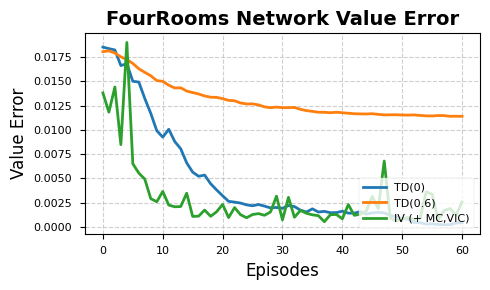

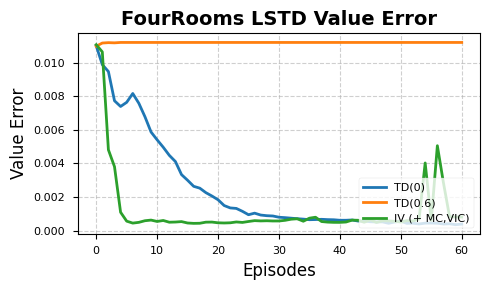

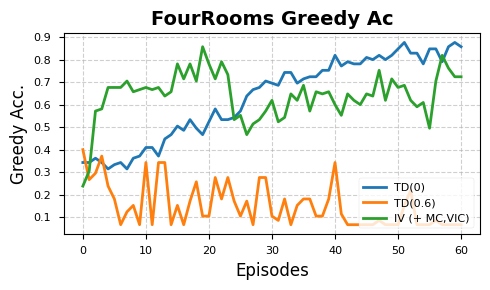

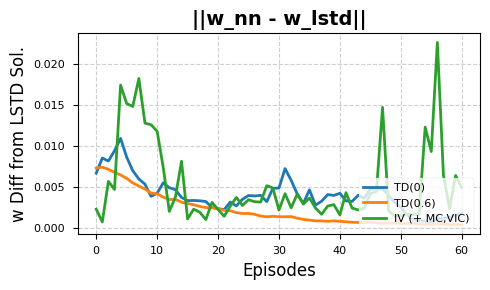

In [3]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
random_td_config, random_td_metrics = load_run_data("random_td/20260518_170809", 'FourRooms-misc', 'results')

random_tdlambda_config, random_tdlambda_metrics = load_run_data("random_td/gae_lambda_06", 'FourRooms-misc', 'results')
random_iv_config, random_iv_metrics = load_run_data("random_iv_model_vic_mc/20260514_170412", 'FourRooms-misc', 'results')

runs = {'TD(0)': random_td_metrics['nn_weighted_VE'],'TD(0.6)': random_tdlambda_metrics['nn_weighted_VE'],'IV (+ MC,VIC)': random_iv_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Network Value Error", y_label = "Value Error")

runs = {'TD(0)': random_td_metrics['LSTD_weighted_VE'],'TD(0.6)': random_tdlambda_metrics['LSTD_weighted_VE'], 'IV (+ MC,VIC)': random_iv_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms LSTD Value Error", y_label = "Value Error")

runs = {'TD(0)': random_td_metrics['nn_greedy_correct'],'TD(0.6)': random_tdlambda_metrics['nn_greedy_correct'] ,  'IV (+ MC,VIC)': random_iv_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD(0)': random_td_metrics['nn_lstd_diff'],'TD(0.6)': random_tdlambda_metrics['nn_lstd_diff']  , 'IV (+ MC,VIC)': random_iv_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

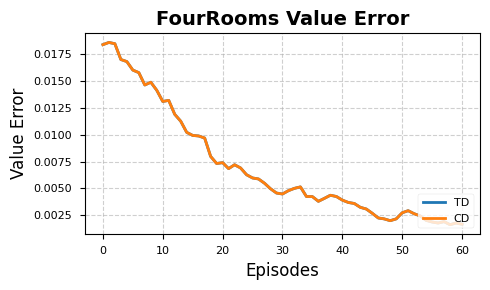

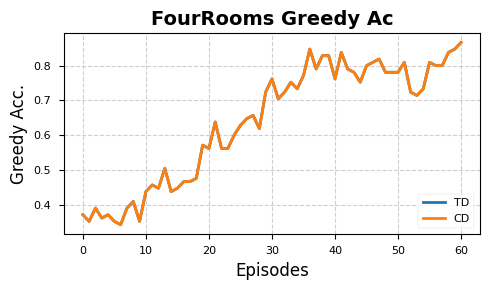

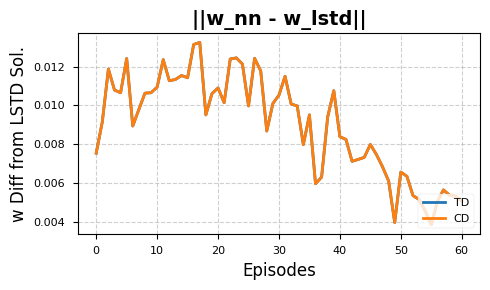

In [7]:
td_config, td_metrics = load_run_data("random_td/no_interfering_factors", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/no_interfering_factors", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

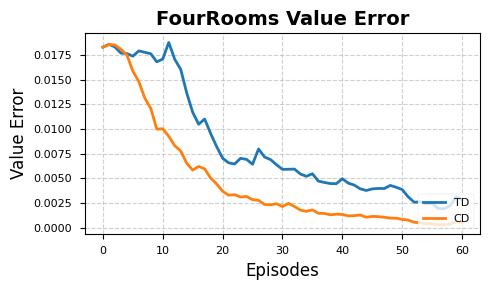

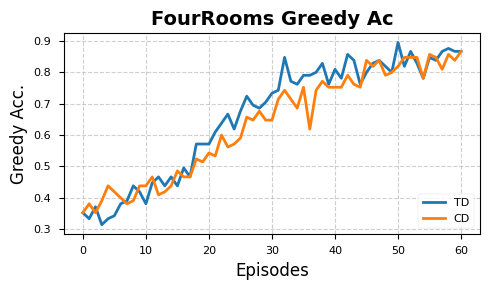

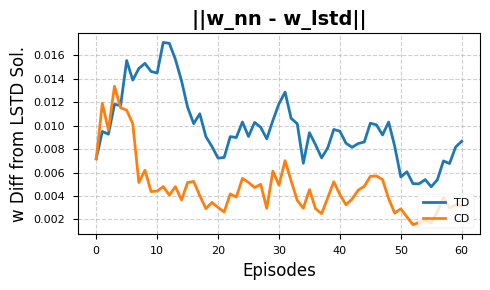

In [5]:
td_config, td_metrics = load_run_data("random_td/20260513_163216", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/20260513_150359", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

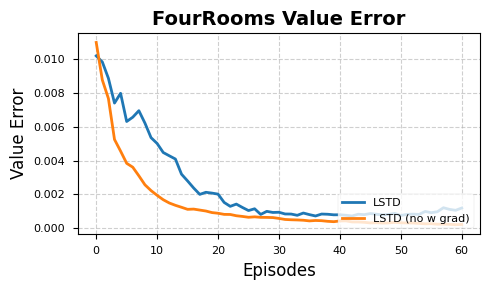

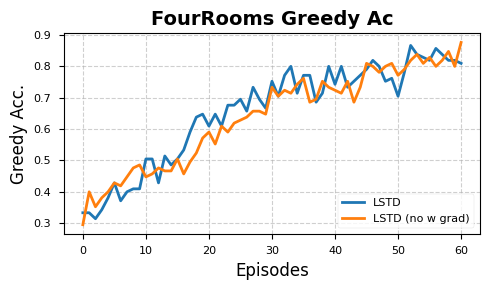

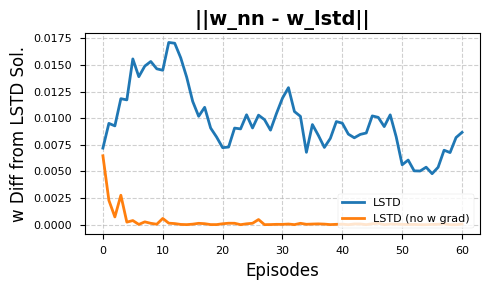

In [52]:
lstd_config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
lstd_cd_config, lstd_cd_metrics = load_run_data("random_lstd/20260513_154513", 'FourRooms-misc', 'results')
lstd_nw_config, lstd_nw_metrics = load_run_data("random_lstd/20260513_160625", 'FourRooms-misc', 'results')

runs = {'LSTD': td_metrics['LSTD_weighted_VE'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'LSTD': td_metrics['LSTD_greedy_correct'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'LSTD': td_metrics['nn_lstd_diff'], 'LSTD (no w grad)': lstd_nw_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

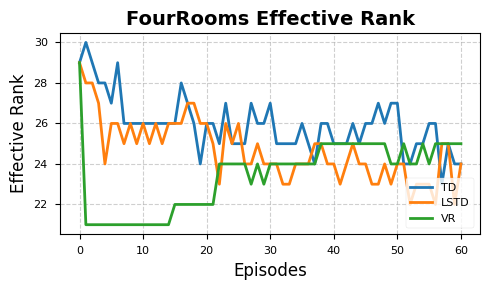

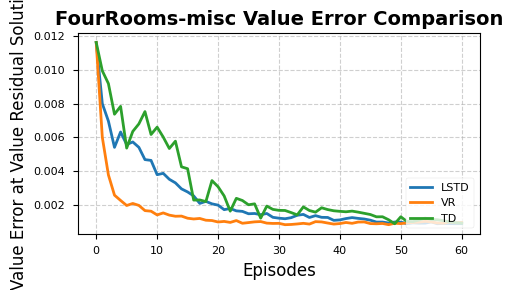

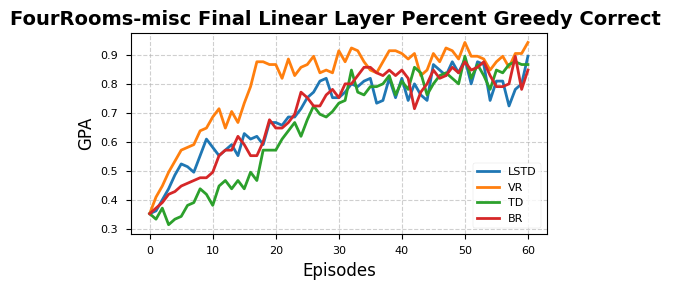

In [38]:
td_config, td_metrics = load_run_data("random_td/20260511_144250", 'FourRooms-misc', 'results')
config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
config, vr_metrics = load_run_data("random_vr/20260511_145817", 'FourRooms-misc', 'results')
config, br_metrics = load_run_data("random_br/20260511_145516", 'FourRooms-misc', 'results')

runs = {
    "TD": td_metrics['effective_rank'],
    "LSTD": lstd_metrics['effective_rank'],
    "VR": vr_metrics['effective_rank'],
    # "BR": br_metrics['effective_rank']
}
plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

runs = {
    "LSTD": lstd_metrics['VR_uniform_VE'],
    "VR": vr_metrics['VR_uniform_VE'],
    "TD": td_metrics['VR_uniform_VE'],
    # "BR": br_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")

runs = {
    "LSTD": lstd_metrics['nn_greedy_correct'],
    "VR": vr_metrics['nn_greedy_correct'],
    "TD": td_metrics['nn_greedy_correct'],
    "BR": br_metrics['nn_greedy_correct']
}

plot_rl_results(runs, title="FourRooms-misc Final Linear Layer Percent Greedy Correct ", y_label = "GPA")

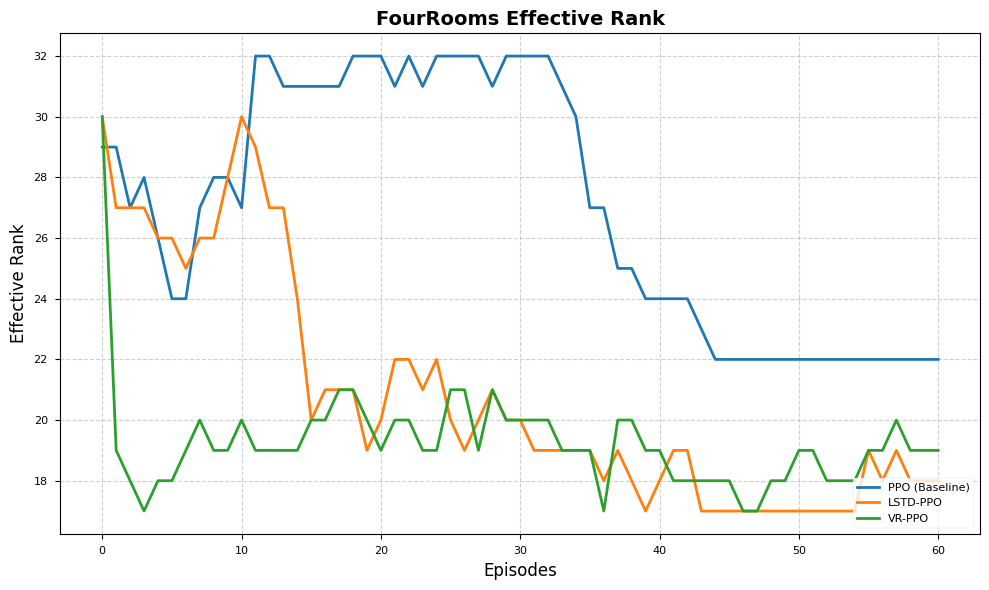

In [ ]:

runs = {
    "PPO (Baseline)": metrics['effective_rank'],
    "LSTD-PPO": lstd_ppo_metrics['effective_rank'],
    "VR-PPO": vr_ppo_metrics['effective_rank']
}

plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

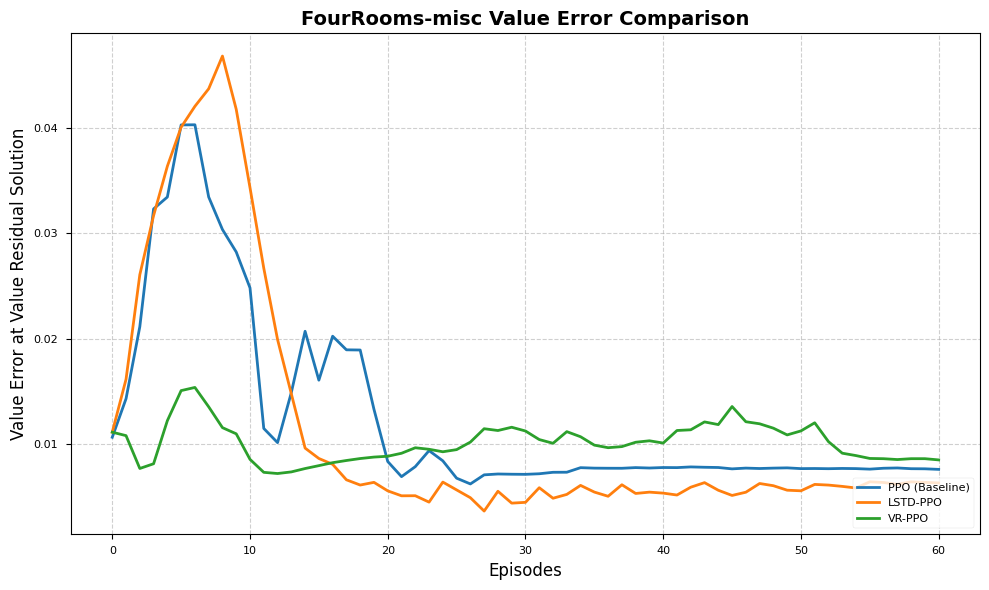

In [31]:
runs = {
    "PPO (Baseline)": metrics['VR_uniform_VE'],
    "LSTD-PPO": lstd_ppo_metrics['VR_uniform_VE'],
    "VR-PPO": vr_ppo_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")


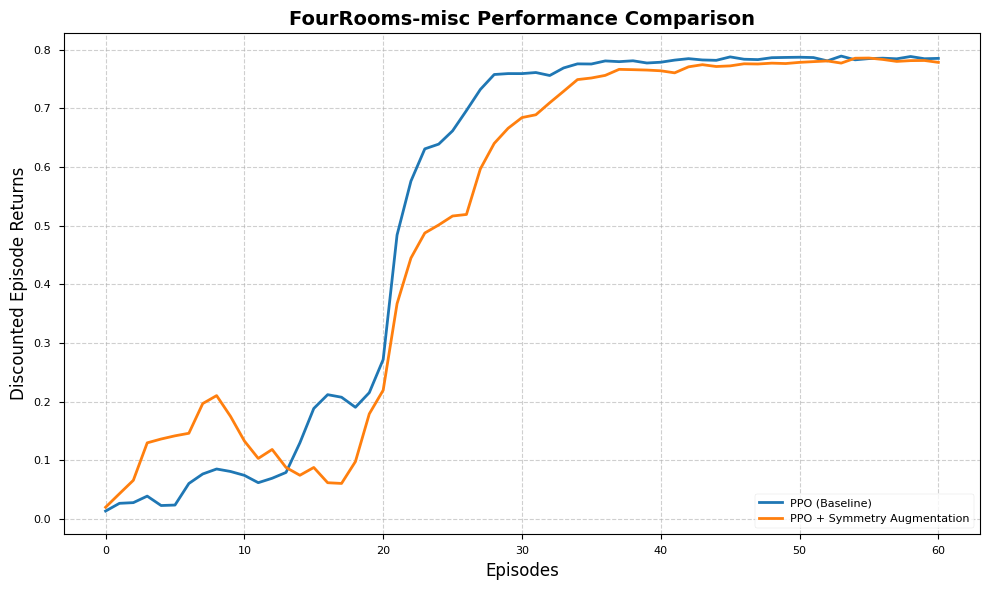

In [35]:
# results/ppo_symmetry_augmentation/20260511_161729/FourRooms-misc/Weightedconfig


ppoconfig, metrics = load_run_data("ppo/20260510_092335", 'FourRooms-misc', 'results')
ppoconfig, symmetrics = load_run_data("ppo_symmetry_augmentation/20260511_161729", 'FourRooms-misc', 'results')

runs = {
    "PPO (Baseline)": metrics['returned_discounted_episode_returns'],
    "PPO + Symmetry Augmentation": symmetrics['returned_discounted_episode_returns']
    
}

plot_rl_results(runs, title="FourRooms-misc Performance Comparison")